In [3]:
import torch
import torch.nn as nn
import numpy as np
import json
import os
import time
import math
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    cohen_kappa_score, top_k_accuracy_score
)
from sklearn.manifold import TSNE
from model import SignLanguageTransformer

# Create output folder for figures
os.makedirs("figures", exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# Load sign labels
with open("sign_to_idx.json") as f:
    sign_to_idx = json.load(f)
idx_to_sign = {v: k for k, v in sign_to_idx.items()}
SIGNS = [idx_to_sign[i] for i in range(22)]
print(f"Signs: {SIGNS}")

Device: cuda
Signs: ['aaja', 'aitabar', 'bal', 'behebar', 'bhat', 'bholi', 'budhabar', 'ghar', 'hami', 'hijo', 'janu', 'khanu', 'khelnu', 'kitab', 'ma', 'manglabar', 'padnu', 'sanibar', 'sombar', 'sukrabar', 'timi', 'uni']


In [4]:
# Load all data
X_train = np.load("X_train.npy")
y_train = np.load("y_train.npy")
X_val   = np.load("X_val.npy")
y_val   = np.load("y_val.npy")
X_test  = np.load("X_test.npy")
y_test  = np.load("y_test.npy")

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")

# Convert to tensors
X_train_t = torch.FloatTensor(X_train).to(DEVICE)
y_train_t = torch.LongTensor(y_train).to(DEVICE)
X_val_t   = torch.FloatTensor(X_val).to(DEVICE)
y_val_t   = torch.LongTensor(y_val).to(DEVICE)
X_test_t  = torch.FloatTensor(X_test).to(DEVICE)
y_test_t  = torch.LongTensor(y_test).to(DEVICE)

# Load model
model = SignLanguageTransformer().to(DEVICE)
model.load_state_dict(torch.load("best_model.pth", map_location=DEVICE))
model.eval()
print("✅ Model loaded!")

# Model size
model_size = os.path.getsize("best_model.pth") / (1024 * 1024)
total_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total_params:,}")
print(f"Model size: {model_size:.2f} MB")

Train: (1415, 25, 225)
Val:   (225, 25, 225)
Test:  (395, 25, 225)
✅ Model loaded!
Parameters: 436,054
Model size: 1.70 MB


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28944\3693036613.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth", map_loc

In [6]:
with torch.no_grad():
    # Test predictions
    test_outputs = model(X_test_t)
    test_probs   = torch.softmax(test_outputs, dim=1)
    test_preds   = test_outputs.argmax(1).cpu().numpy()
    test_true    = y_test_t.cpu().numpy()
    test_probs_np = test_probs.cpu().numpy()

    # Train predictions (for loss curve reconstruction)
    train_outputs = model(X_train_t)
    train_preds   = train_outputs.argmax(1).cpu().numpy()

print("✅ Predictions done!")
print(f"Test Accuracy: {(test_preds == test_true).mean():.4f}")

✅ Predictions done!
Test Accuracy: 0.5392


In [7]:
# Accuracy
accuracy = (test_preds == test_true).mean()

# Top-3 accuracy
top3_acc = top_k_accuracy_score(test_true, test_probs_np, k=3)

# Cohen's Kappa
kappa = cohen_kappa_score(test_true, test_preds)

# Classification report
report = classification_report(
    test_true, test_preds,
    target_names=SIGNS,
    output_dict=True
)

print("=" * 50)
print(f"Test Accuracy:    {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Top-3 Accuracy:   {top3_acc:.4f} ({top3_acc*100:.2f}%)")
print(f"Cohen's Kappa:    {kappa:.4f}")
print(f"Macro F1:         {report['macro avg']['f1-score']:.4f}")
print(f"Weighted F1:      {report['weighted avg']['f1-score']:.4f}")
print(f"Macro Precision:  {report['macro avg']['precision']:.4f}")
print(f"Macro Recall:     {report['macro avg']['recall']:.4f}")
print(f"Parameters:       {total_params:,}")
print(f"Model Size:       {model_size:.2f} MB")
print(f"Random Baseline:  {1/22*100:.2f}%")
print(f"Improvement:      {accuracy/(1/22):.1f}x over random")
print("=" * 50)

# Print full classification report
print("\nFull Classification Report:")
print(classification_report(test_true, test_preds, target_names=SIGNS))

Test Accuracy:    0.5392 (53.92%)
Top-3 Accuracy:   0.8127 (81.27%)
Cohen's Kappa:    0.5172
Macro F1:         0.5194
Weighted F1:      0.5189
Macro Precision:  0.5232
Macro Recall:     0.5392
Parameters:       436,054
Model Size:       1.70 MB
Random Baseline:  4.55%
Improvement:      11.9x over random

Full Classification Report:
              precision    recall  f1-score   support

        aaja       0.38      0.79      0.51        19
     aitabar       0.67      0.53      0.59        19
         bal       0.42      0.58      0.49        19
     behebar       0.69      1.00      0.82        18
        bhat       0.42      0.31      0.36        16
       bholi       0.00      0.00      0.00        19
    budhabar       0.74      0.88      0.80        16
        ghar       0.86      0.95      0.90        19
        hami       0.18      0.11      0.14        18
        hijo       0.44      0.65      0.52        17
        janu       0.50      0.39      0.44        18
       khanu     

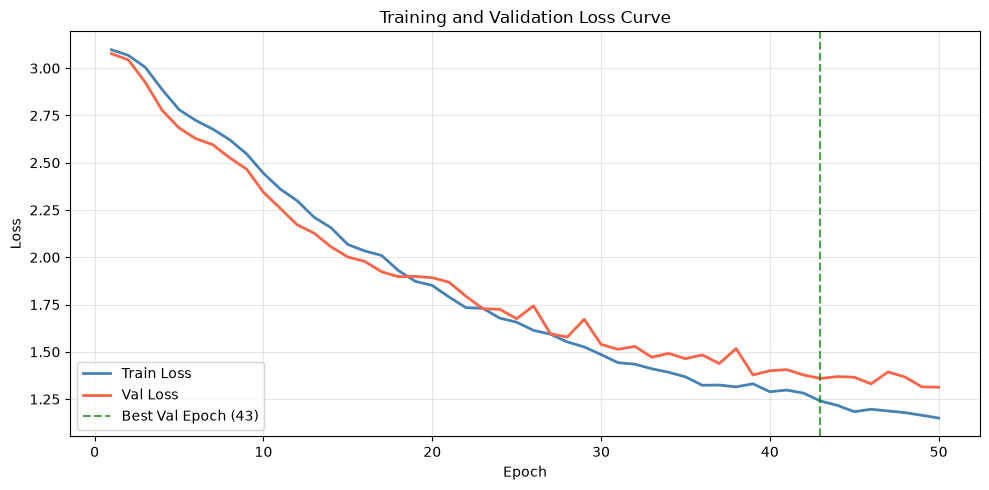

✅ Loss curve saved


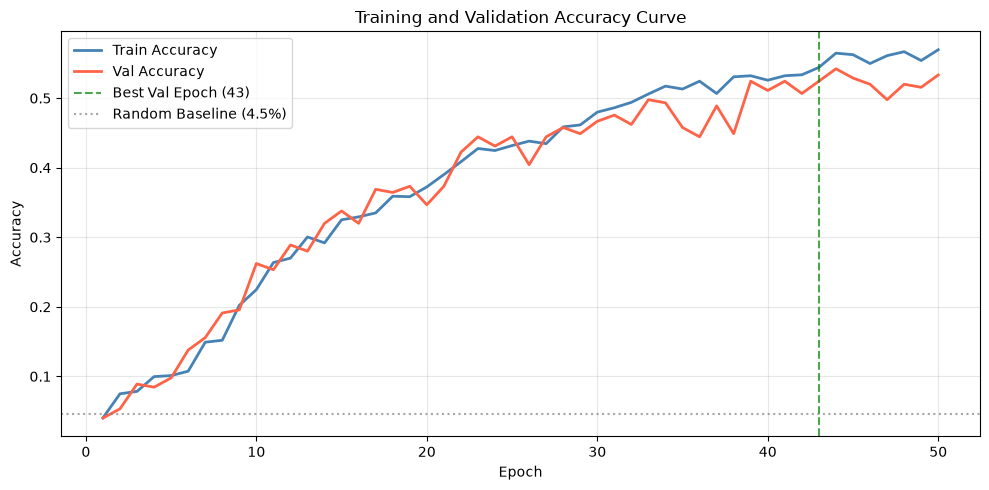

✅ Accuracy curve saved


In [8]:
# Training history — paste your epoch logs here
train_losses = [
    3.0976, 3.0678, 3.0048, 2.8871, 2.7810,
    2.7234, 2.6778, 2.6217, 2.5472, 2.4445,
    2.3606, 2.2990, 2.2121, 2.1565, 2.0676,
    2.0337, 2.0098, 1.9295, 1.8729, 1.8511,
    1.7897, 1.7334, 1.7302, 1.6784, 1.6569,
    1.6135, 1.5934, 1.5525, 1.5261, 1.4857,
    1.4429, 1.4348, 1.4107, 1.3920, 1.3678,
    1.3231, 1.3244, 1.3147, 1.3309, 1.2890,
    1.2980, 1.2816, 1.2399, 1.2169, 1.1837,
    1.1962, 1.1875, 1.1785, 1.1647, 1.1497
]

val_losses = [
    3.0771, 3.0435, 2.9253, 2.7770, 2.6842,
    2.6270, 2.5955, 2.5260, 2.4663, 2.3439,
    2.2582, 2.1717, 2.1276, 2.0555, 2.0016,
    1.9783, 1.9233, 1.8972, 1.8990, 1.8920,
    1.8683, 1.7936, 1.7280, 1.7248, 1.6750,
    1.7432, 1.5955, 1.5783, 1.6722, 1.5393,
    1.5136, 1.5288, 1.4718, 1.4918, 1.4638,
    1.4838, 1.4380, 1.5173, 1.3778, 1.4002,
    1.4058, 1.3775, 1.3593, 1.3691, 1.3658,
    1.3307, 1.3938, 1.3672, 1.3149, 1.3129
]

train_accs = [
    0.0403, 0.0749, 0.0784, 0.0996, 0.1011,
    0.1074, 0.1491, 0.1519, 0.2021, 0.2247,
    0.2636, 0.2700, 0.3004, 0.2919, 0.3251,
    0.3293, 0.3350, 0.3590, 0.3583, 0.3724,
    0.3901, 0.4085, 0.4276, 0.4247, 0.4318,
    0.4382, 0.4346, 0.4587, 0.4615, 0.4799,
    0.4862, 0.4940, 0.5060, 0.5173, 0.5131,
    0.5244, 0.5067, 0.5307, 0.5322, 0.5258,
    0.5322, 0.5336, 0.5442, 0.5647, 0.5625,
    0.5498, 0.5611, 0.5668, 0.5541, 0.5696
]

val_accs = [
    0.0400, 0.0533, 0.0889, 0.0844, 0.0978,
    0.1378, 0.1556, 0.1911, 0.1956, 0.2622,
    0.2533, 0.2889, 0.2800, 0.3200, 0.3378,
    0.3200, 0.3689, 0.3644, 0.3733, 0.3467,
    0.3733, 0.4222, 0.4444, 0.4311, 0.4444,
    0.4044, 0.4444, 0.4578, 0.4489, 0.4667,
    0.4756, 0.4622, 0.4978, 0.4933, 0.4578,
    0.4444, 0.4889, 0.4489, 0.5244, 0.5111,
    0.5244, 0.5067, 0.5244, 0.5422, 0.5289,
    0.5200, 0.4978, 0.5200, 0.5156, 0.5333
]

epochs = list(range(1, 51))

# ── Loss Curve ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs, train_losses, label='Train Loss', color='steelblue', linewidth=2)
ax.plot(epochs, val_losses,   label='Val Loss',   color='tomato',    linewidth=2)
ax.axvline(x=43, color='green', linestyle='--', alpha=0.7, label='Best Val Epoch (43)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training and Validation Loss Curve')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/loss_curve.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Loss curve saved")

# ── Accuracy Curve ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs, train_accs, label='Train Accuracy', color='steelblue', linewidth=2)
ax.plot(epochs, val_accs,   label='Val Accuracy',   color='tomato',    linewidth=2)
ax.axvline(x=43, color='green', linestyle='--', alpha=0.7, label='Best Val Epoch (43)')
ax.axhline(y=1/22, color='gray', linestyle=':', alpha=0.7, label='Random Baseline (4.5%)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Training and Validation Accuracy Curve')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/acc_curve.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Accuracy curve saved")

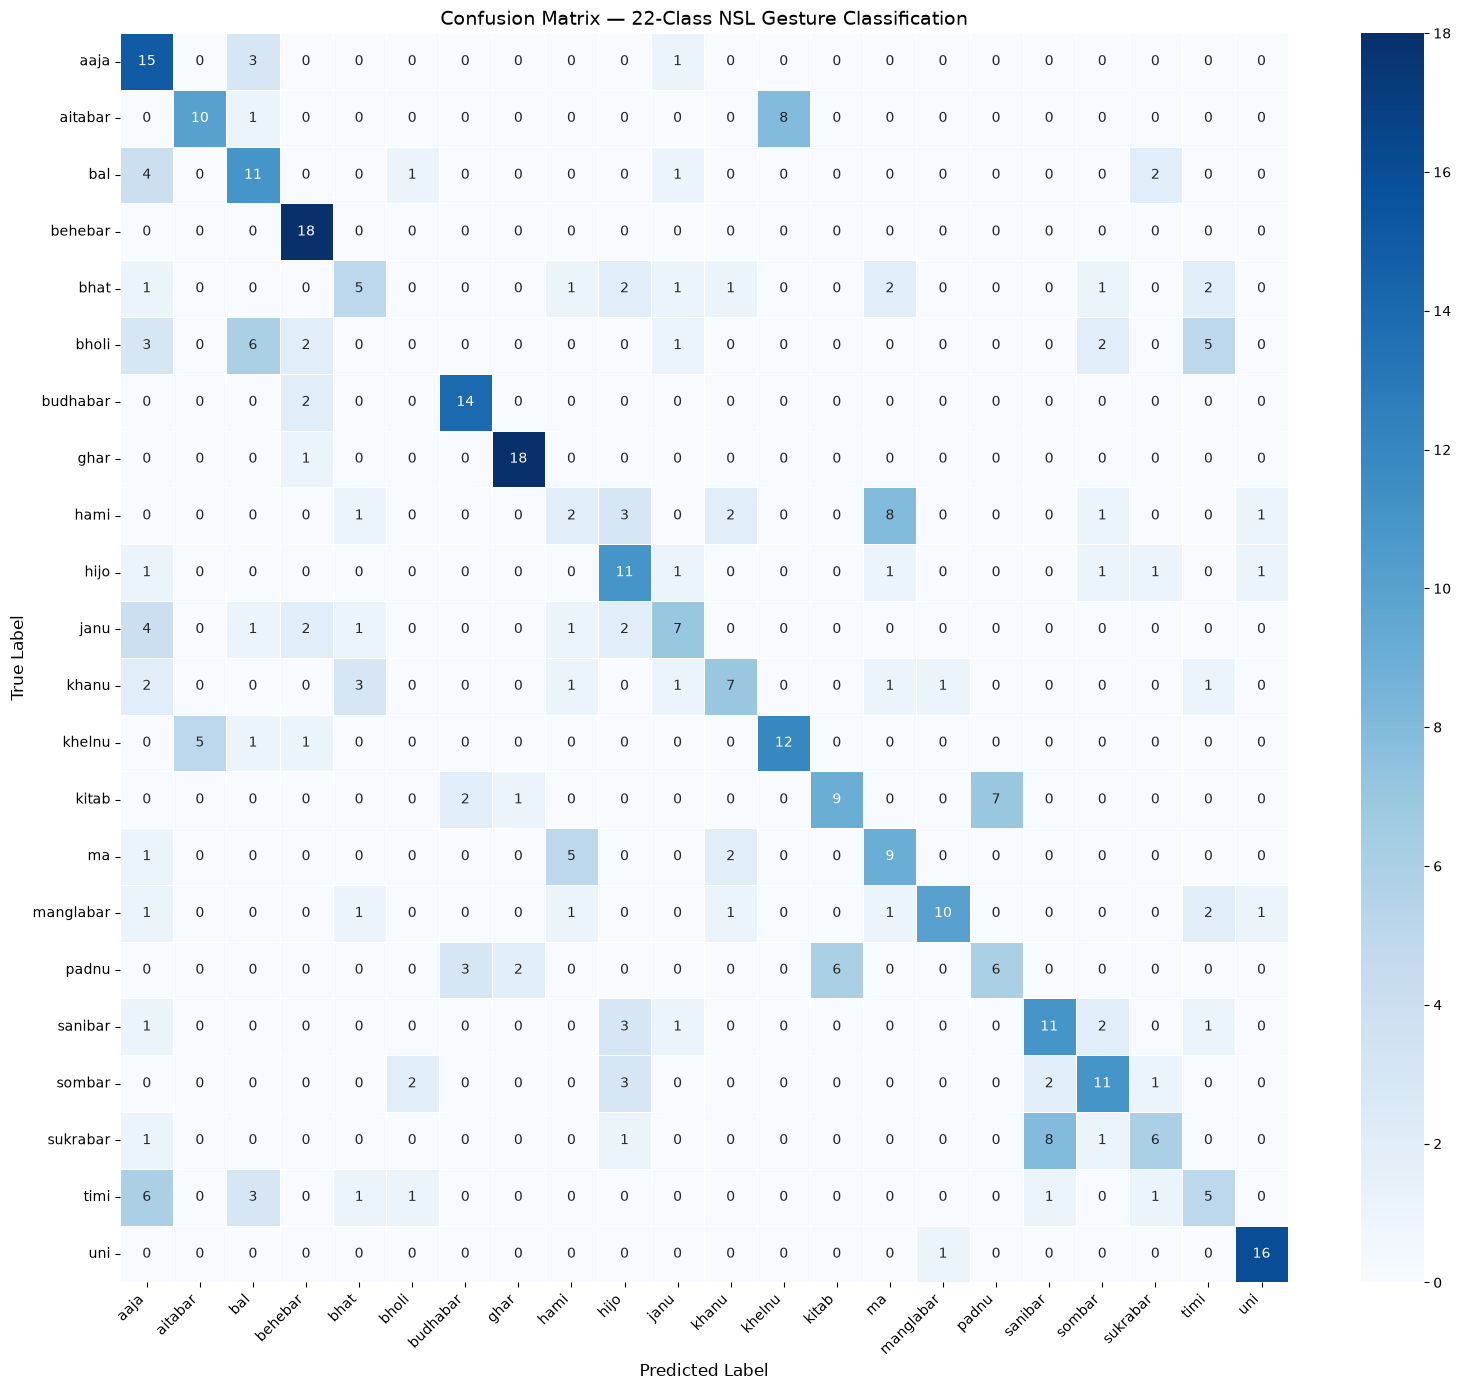

✅ Confusion matrix saved


In [9]:
cm = confusion_matrix(test_true, test_preds)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=SIGNS,
    yticklabels=SIGNS,
    ax=ax,
    linewidths=0.5
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix — 22-Class NSL Gesture Classification', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("figures/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved")

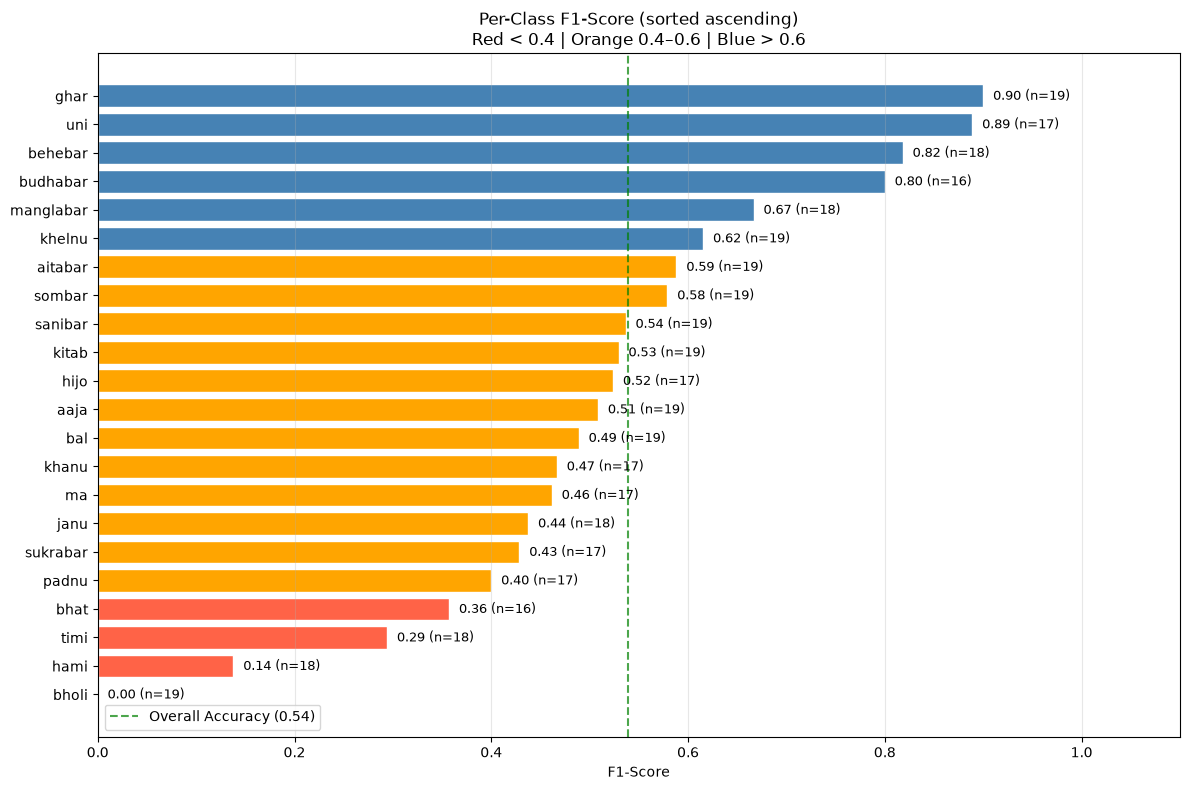

✅ F1 bar chart saved


In [10]:
f1_scores = [report[sign]['f1-score'] for sign in SIGNS]
support   = [report[sign]['support']  for sign in SIGNS]

# Sort ascending by F1
sorted_pairs = sorted(zip(f1_scores, SIGNS, support))
sorted_f1    = [x[0] for x in sorted_pairs]
sorted_signs = [x[1] for x in sorted_pairs]
sorted_supp  = [x[2] for x in sorted_pairs]

colors = ['tomato' if f < 0.4 else 'orange' if f < 0.6 else 'steelblue'
          for f in sorted_f1]

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(sorted_signs, sorted_f1, color=colors, edgecolor='white')

# Add value labels + support
for bar, f1, supp in zip(bars, sorted_f1, sorted_supp):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{f1:.2f} (n={int(supp)})',
            va='center', fontsize=9)

ax.set_xlabel('F1-Score')
ax.set_title('Per-Class F1-Score (sorted ascending)\nRed < 0.4 | Orange 0.4–0.6 | Blue > 0.6')
ax.set_xlim(0, 1.1)
ax.axvline(x=accuracy, color='green', linestyle='--',
           alpha=0.7, label=f'Overall Accuracy ({accuracy:.2f})')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig("figures/f1_barchart.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ F1 bar chart saved")

Extracting embeddings...
Embeddings shape: (395, 128)
Running t-SNE (this takes ~1 min)...
✅ t-SNE done!


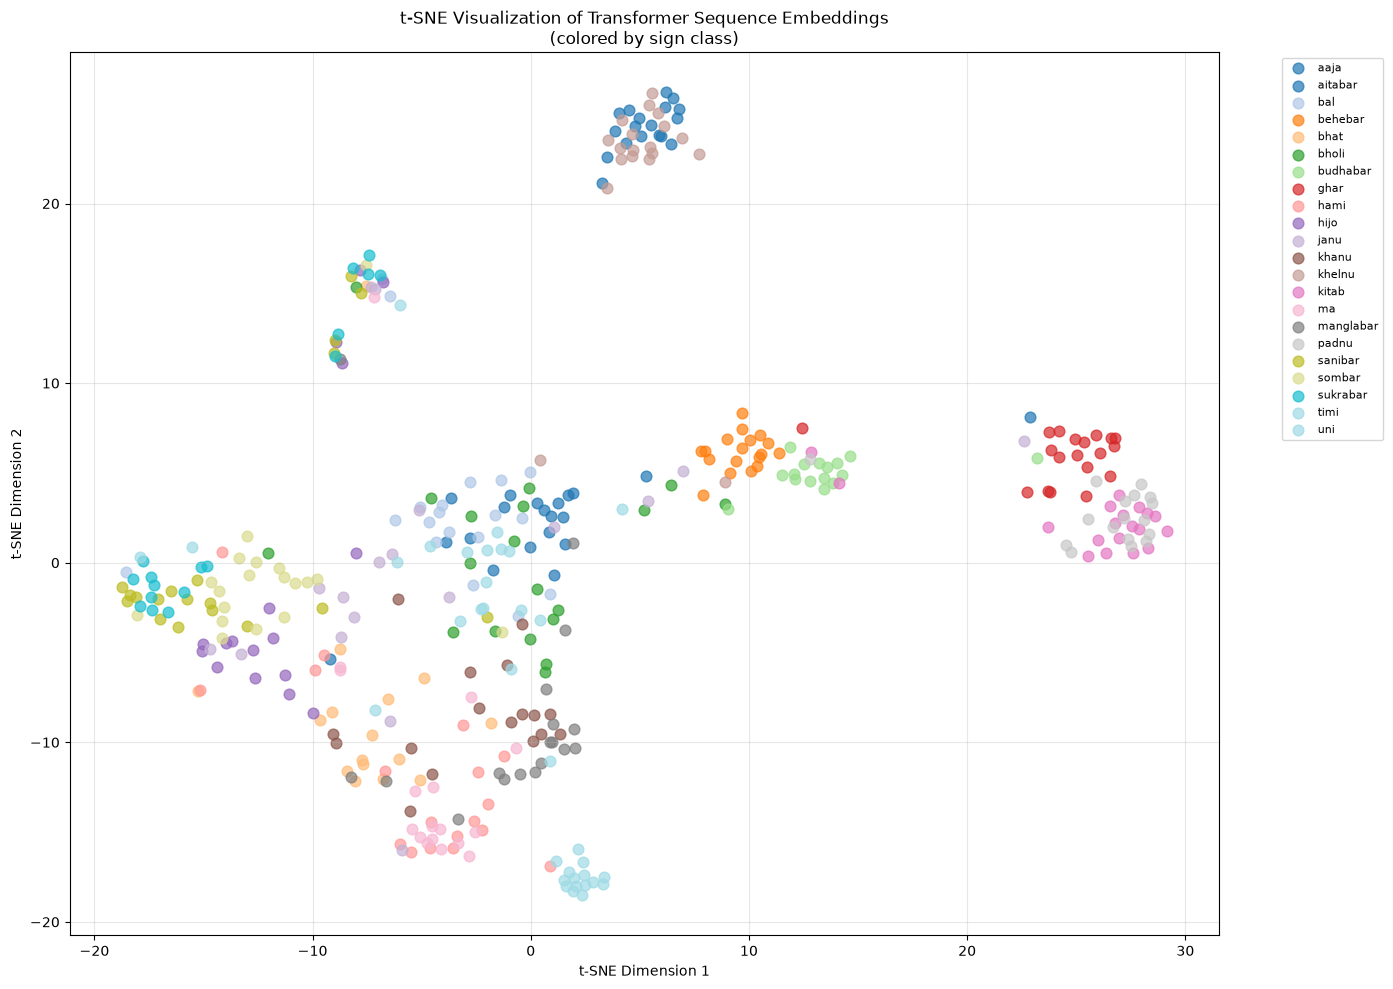

✅ t-SNE saved


In [12]:
# Extract embeddings from penultimate layer
def get_embeddings(model, X_tensor):
    embeddings = []

    def hook_fn(module, input, output):
        embeddings.append(output.detach().cpu().numpy())

    # Hook on the mean pooling output
    # We modify forward temporarily
    model.eval()
    with torch.no_grad():
        x = model.input_projection(X_tensor)
        x = model.pos_encoding(x)
        for block in model.encoder_blocks:
            x = block(x)
        x = x.mean(dim=1)  # pooled embeddings
    return x.cpu().numpy()

print("Extracting embeddings...")
embeddings = get_embeddings(model, X_test_t)
print(f"Embeddings shape: {embeddings.shape}")

# t-SNE
print("Running t-SNE (this takes ~1 min)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings)
print("✅ t-SNE done!")

# Plot
fig, ax = plt.subplots(figsize=(14, 10))
colors = plt.cm.tab20(np.linspace(0, 1, 22))

for i, sign in enumerate(SIGNS):
    mask = test_true == i
    ax.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=[colors[i]],
        label=sign,
        alpha=0.7,
        s=60
    )

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',
          fontsize=8, ncol=1)
ax.set_title('t-SNE Visualization of Transformer Sequence Embeddings\n(colored by sign class)')
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/tsne.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ t-SNE saved")

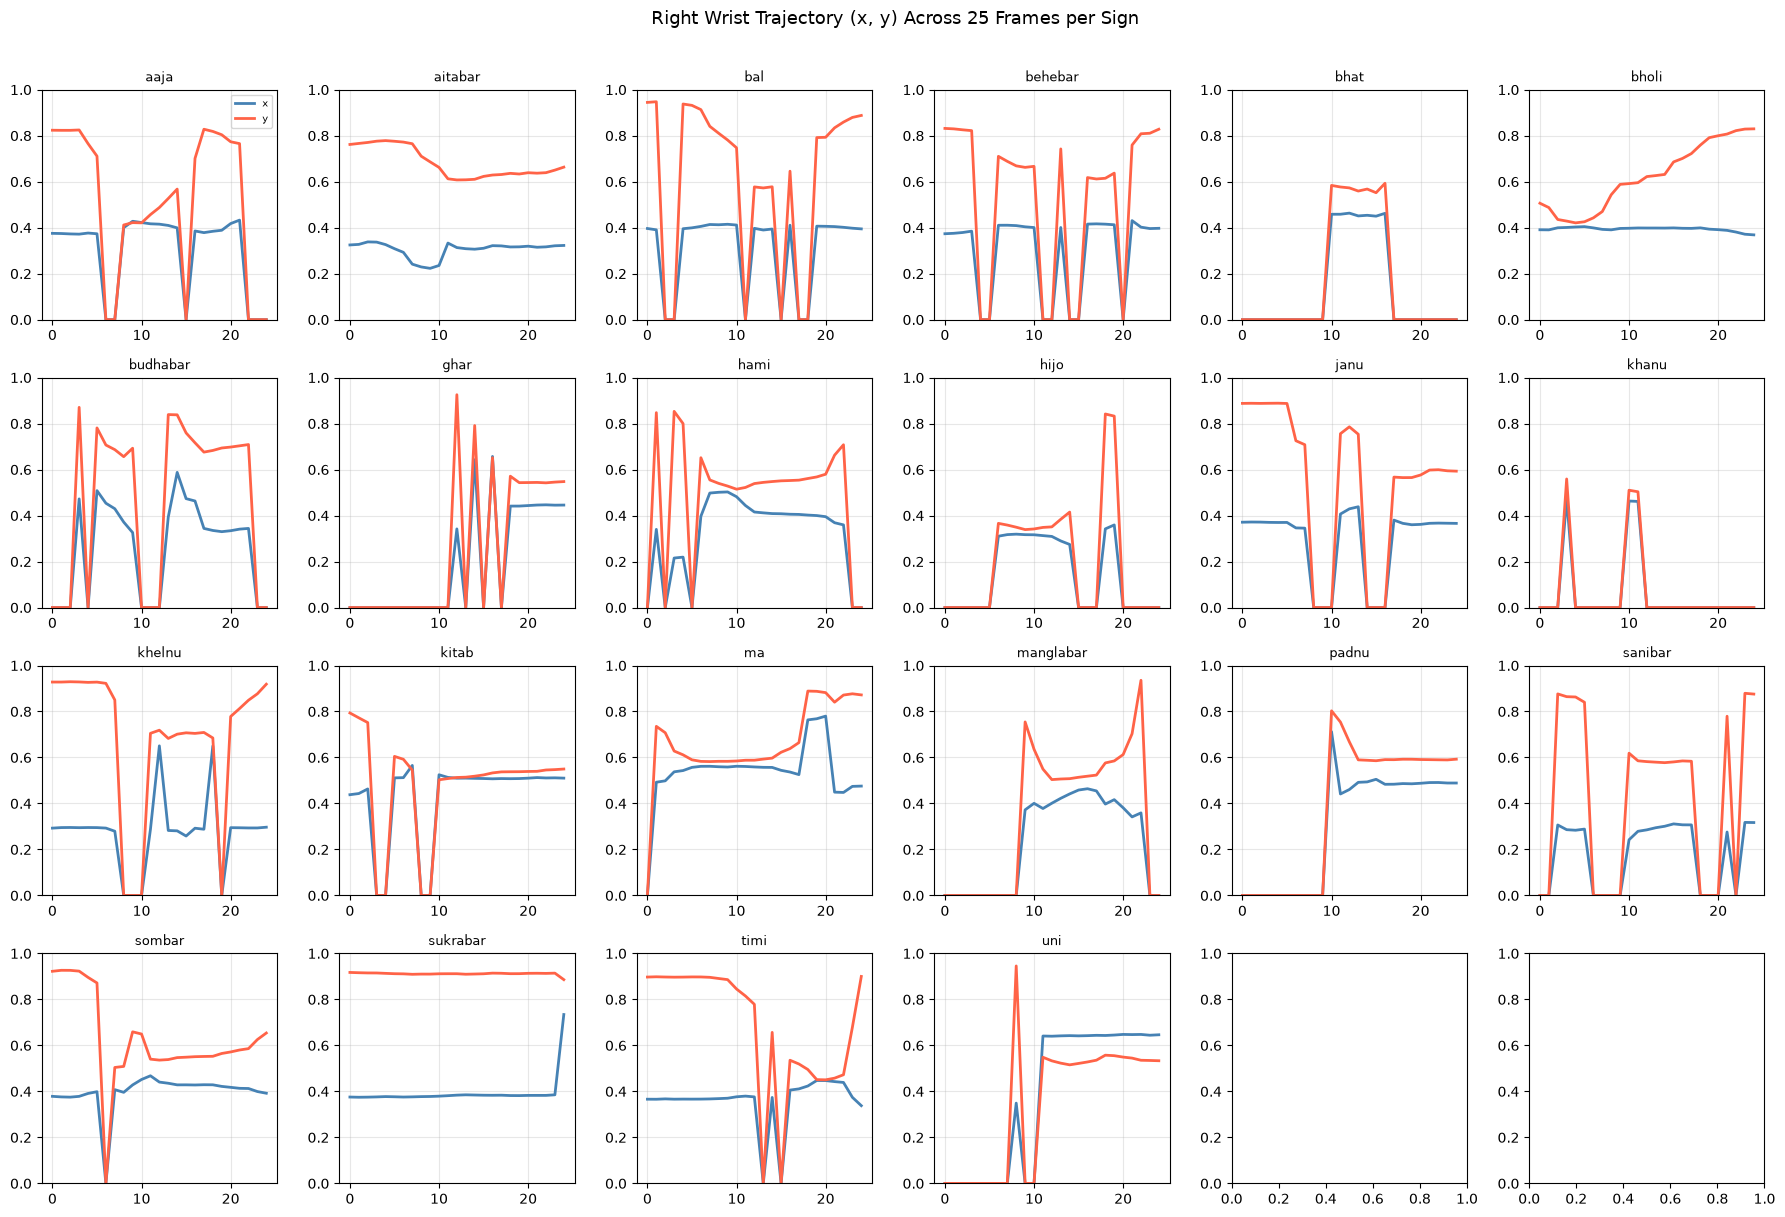

✅ Wrist trajectory saved


In [13]:
# Plot wrist x,y trajectory across 25 frames for each sign
fig, axes = plt.subplots(4, 6, figsize=(18, 12))
axes = axes.flatten()

for i, sign in enumerate(SIGNS):
    # Get first test sample of this sign
    mask = test_true == i
    if mask.sum() == 0:
        continue

    sample = X_test[mask][0]  # shape (25, 225)

    # Right wrist = landmark 0 of right hand
    # Right hand starts at index 63 (after left hand)
    # x = index 63, y = index 64
    right_wrist_x = sample[:, 63]
    right_wrist_y = sample[:, 64]

    frames = list(range(25))
    axes[i].plot(frames, right_wrist_x, label='x', color='steelblue', linewidth=2)
    axes[i].plot(frames, right_wrist_y, label='y', color='tomato',    linewidth=2)
    axes[i].set_title(sign, fontsize=9)
    axes[i].set_ylim(0, 1)
    axes[i].grid(True, alpha=0.3)
    if i == 0:
        axes[i].legend(fontsize=7)

fig.suptitle('Right Wrist Trajectory (x, y) Across 25 Frames per Sign',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("figures/wrist_trajectory.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Wrist trajectory saved")

In [14]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import cv2
from tqdm import tqdm

dataset_path = r"E:\Dataset_Sign_Language\organized_dataset_word"

# Setup MediaPipe
hand_base = python.BaseOptions(model_asset_path="hand_landmarker.task")
hand_options = vision.HandLandmarkerOptions(
    base_options=hand_base,
    running_mode=vision.RunningMode.IMAGE,
    num_hands=2,
    min_hand_detection_confidence=0.3,
)
hand_landmarker = vision.HandLandmarker.create_from_options(hand_options)

pose_base = python.BaseOptions(model_asset_path="pose_landmarker.task")
pose_options = vision.PoseLandmarkerOptions(
    base_options=pose_base,
    running_mode=vision.RunningMode.IMAGE,
    min_pose_detection_confidence=0.3,
)
pose_landmarker = vision.PoseLandmarker.create_from_options(pose_options)

# Analyze detection per sign
detection_stats = {}
total_frames = 0
total_pose   = 0
total_lhand  = 0
total_rhand  = 0
total_both   = 0
total_either = 0

train_path = os.path.join(dataset_path, "train")

for sign in SIGNS:
    sign_path = os.path.join(train_path, sign)
    if not os.path.exists(sign_path):
        continue

    videos = sorted(os.listdir(sign_path))
    sign_total  = 0
    sign_pose   = 0
    sign_lhand  = 0
    sign_rhand  = 0
    sign_missing = 0

    for video in videos:
        video_path = os.path.join(sign_path, video)
        frames = sorted(os.listdir(video_path))

        for frame_name in frames:
            frame_path = os.path.join(video_path, frame_name)
            mp_image = mp.Image.create_from_file(frame_path)

            hand_result = hand_landmarker.detect(mp_image)
            pose_result = pose_landmarker.detect(mp_image)

            sign_total += 1

            if pose_result.pose_landmarks:
                sign_pose += 1

            has_left  = False
            has_right = False

            if hand_result.hand_landmarks:
                for i, hand in enumerate(hand_result.hand_landmarks):
                    h = hand_result.handedness[i][0].display_name
                    if h == "Left":
                        has_left  = True
                        sign_lhand += 1
                    else:
                        has_right = True
                        sign_rhand += 1

            if not has_left and not has_right:
                sign_missing += 1

    detection_stats[sign] = {
        'total':   sign_total,
        'pose':    sign_pose,
        'lhand':   sign_lhand,
        'rhand':   sign_rhand,
        'missing': sign_missing
    }

    total_frames += sign_total
    total_pose   += sign_pose
    total_lhand  += sign_lhand
    total_rhand  += sign_rhand
    total_both   += min(sign_lhand, sign_rhand)
    total_either += (sign_total - sign_missing)

    print(f"{sign:12s}: total={sign_total} "
          f"pose={sign_pose/sign_total*100:.0f}% "
          f"lhand={sign_lhand/sign_total*100:.0f}% "
          f"rhand={sign_rhand/sign_total*100:.0f}% "
          f"missing={sign_missing/sign_total*100:.0f}%")

print(f"\n{'='*60}")
print(f"TOTAL FRAMES:      {total_frames}")
print(f"Pose detected:     {total_pose} ({total_pose/total_frames*100:.1f}%)")
print(f"Left hand:         {total_lhand} ({total_lhand/total_frames*100:.1f}%)")
print(f"Right hand:        {total_rhand} ({total_rhand/total_frames*100:.1f}%)")
print(f"At least one hand: {total_either} ({total_either/total_frames*100:.1f}%)")

aaja        : total=1666 pose=100% lhand=76% rhand=85% missing=6%
aitabar     : total=1693 pose=100% lhand=86% rhand=83% missing=9%
bal         : total=1674 pose=100% lhand=80% rhand=86% missing=6%
behebar     : total=1675 pose=100% lhand=68% rhand=73% missing=17%
bhat        : total=1665 pose=100% lhand=80% rhand=69% missing=10%
bholi       : total=1661 pose=100% lhand=76% rhand=84% missing=8%
budhabar    : total=1696 pose=100% lhand=69% rhand=82% missing=13%
ghar        : total=1659 pose=100% lhand=77% rhand=80% missing=15%
hami        : total=1671 pose=100% lhand=81% rhand=69% missing=9%
hijo        : total=1665 pose=100% lhand=80% rhand=70% missing=11%
janu        : total=1688 pose=100% lhand=77% rhand=71% missing=12%
khanu       : total=1669 pose=100% lhand=77% rhand=76% missing=10%
khelnu      : total=1696 pose=100% lhand=84% rhand=87% missing=9%
kitab       : total=1673 pose=100% lhand=79% rhand=79% missing=9%
ma          : total=1631 pose=100% lhand=77% rhand=79% missing=9%
man

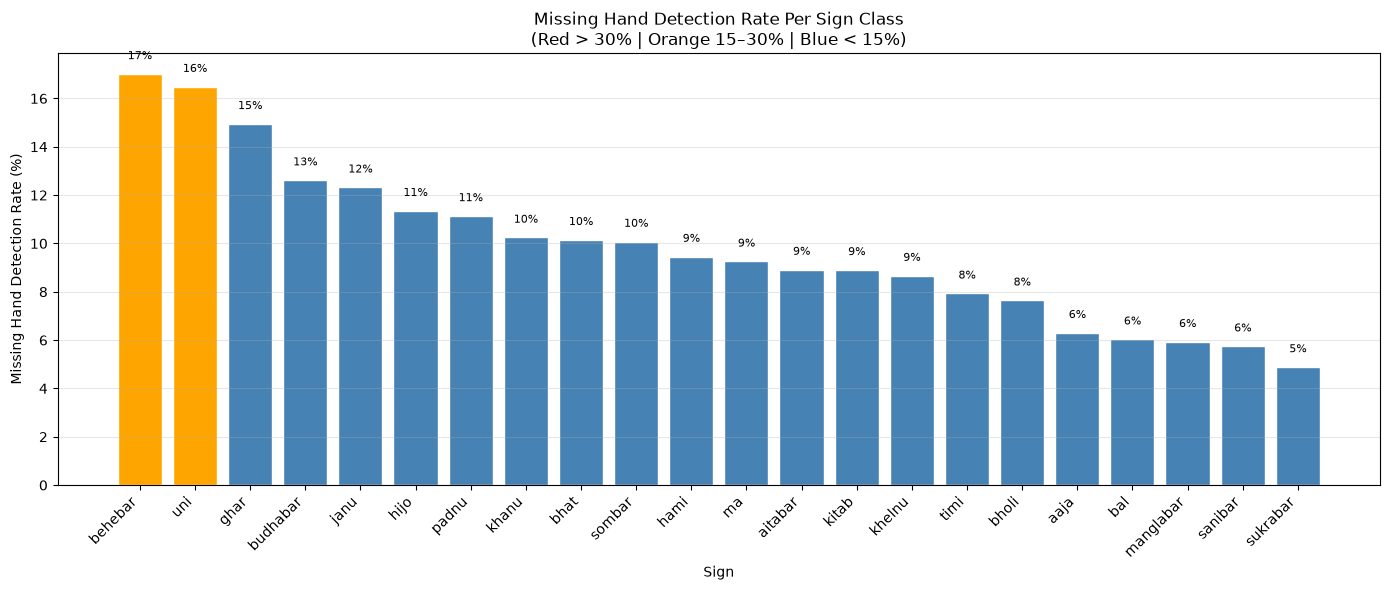

✅ Detection rate chart saved


In [15]:
fig, ax = plt.subplots(figsize=(14, 6))

signs_list   = list(detection_stats.keys())
missing_rates = [
    detection_stats[s]['missing'] / detection_stats[s]['total'] * 100
    for s in signs_list
]

sorted_pairs  = sorted(zip(missing_rates, signs_list), reverse=True)
sorted_rates  = [x[0] for x in sorted_pairs]
sorted_signs2 = [x[1] for x in sorted_pairs]

colors = ['tomato' if r > 30 else 'orange' if r > 15 else 'steelblue'
          for r in sorted_rates]

bars = ax.bar(sorted_signs2, sorted_rates, color=colors, edgecolor='white')
ax.set_xlabel('Sign')
ax.set_ylabel('Missing Hand Detection Rate (%)')
ax.set_title('Missing Hand Detection Rate Per Sign Class\n(Red > 30% | Orange 15–30% | Blue < 15%)')
plt.xticks(rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

for bar, rate in zip(bars, sorted_rates):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{rate:.0f}%',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig("figures/detection_rate.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Detection rate chart saved")

In [16]:
import time

model.eval()

# Warm up GPU
dummy = torch.randn(1, 25, 225).to(DEVICE)
for _ in range(10):
    with torch.no_grad():
        _ = model(dummy)

# Measure latency
N_RUNS = 100
times  = []

for _ in range(N_RUNS):
    x = torch.randn(1, 25, 225).to(DEVICE)
    start = time.perf_counter()
    with torch.no_grad():
        _ = model(x)
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
    end = time.perf_counter()
    times.append((end - start) * 1000)  # ms

avg_latency = np.mean(times)
std_latency = np.std(times)

print(f"Inference Latency (per sample):")
print(f"  Mean: {avg_latency:.2f} ms")
print(f"  Std:  {std_latency:.2f} ms")
print(f"  Min:  {np.min(times):.2f} ms")
print(f"  Max:  {np.max(times):.2f} ms")
print(f"  Throughput: {1000/avg_latency:.0f} samples/sec")

Inference Latency (per sample):
  Mean: 5.72 ms
  Std:  4.00 ms
  Min:  1.52 ms
  Max:  15.31 ms
  Throughput: 175 samples/sec


In [ ]:
print("\n" + "="*60)
print("COMPLETE RESULTS SUMMARY")
print("="*60)
print(f"\n── Transformer Classifier ──")
print(f"Test Accuracy:      {accuracy*100:.2f}%")
print(f"Top-3 Accuracy:     {top3_acc*100:.2f}%")
print(f"Cohen's Kappa:      {kappa:.4f}")
print(f"Macro F1:           {report['macro avg']['f1-score']:.4f}")
print(f"Weighted F1:        {report['weighted avg']['f1-score']:.4f}")
print(f"Parameters:         {total_params:,}")
print(f"Model Size:         {model_size:.2f} MB")
print(f"Inference Latency:  {avg_latency:.2f} ± {std_latency:.2f} ms")

print(f"\n── MediaPipe Extraction ──")
print(f"Total Frames:       {total_frames}")
print(f"Pose Detection:     {total_pose/total_frames*100:.1f}%")
print(f"Left Hand:          {total_lhand/total_frames*100:.1f}%")
print(f"Right Hand:         {total_rhand/total_frames*100:.1f}%")
print(f"At Least One Hand:  {total_either/total_frames*100:.1f}%")

print(f"\n── Figures Saved -──")
for f in os.listdir("figures"):
    size = os.path.getsize(f"figures/{f}") / 1024
    print(f"  {f:35s} {size:.0f} KB")

print("\n✅ All done! Copy figures/ to your LaTeX src/images/figures/ folder")


COMPLETE RESULTS SUMMARY

── Transformer Classifier ──
Test Accuracy:      53.92%
Top-3 Accuracy:     81.27%
Cohen's Kappa:      0.5172
Macro F1:           0.5194
Weighted F1:        0.5189
Parameters:         436,054
Model Size:         1.70 MB
Inference Latency:  5.72 ± 4.00 ms

── MediaPipe Extraction ──
Total Frames:       36856
Pose Detection:     100.0%
Left Hand:          75.9%
Right Hand:         79.2%
At Least One Hand:  90.2%

── Figures Saved ──
  acc_curve.png                       82 KB
  confusion_matrix.png                270 KB
  detection_rate.png                  85 KB
  f1_barchart.png                     109 KB
  loss_curve.png                      76 KB
  tsne.png                            253 KB
  wrist_trajectory.png                419 KB

✅ All done! Copy figures/ to your LaTeX src/images/figures/ folder
